Marnowanie żywności stanowi jeden z istotnych problemów współczesnego świata, wpływając zarówno na gospodarkę, jak i środowisko naturalne. Według różnych szacunków znacząca część produkowanej żywności nie trafia do konsumentów lub zostaje wyrzucona na różnych etapach łańcucha dostaw.

Celem niniejszej analizy jest zbadanie skali marnowania żywności w różnych krajach świata oraz identyfikacja czynników, które mogą wpływać na poziom tego zjawiska. W szczególności analizie poddano zależności pomiędzy poziomem marnowania żywności a poziomem dochodu krajów, regionem geograficznym oraz sektorem, w którym powstają straty żywności.

In [1]:
import pandas as pd
marnowanie_zywnosci = '/content/drive/MyDrive/marnowanie żywności/Food Waste data and research - by country.csv'
klasyfikacja_krajów = '/content/drive/MyDrive/marnowanie żywności/worldbank_classification.csv'

food = pd.read_csv(marnowanie_zywnosci)
income = pd.read_csv(klasyfikacja_krajów)

food.head()
income.head()

print(food.head())
print(income.head())

       Country  combined figures (kg/capita/year)  \
0  Afghanistan                                126   
1      Albania                                127   
2      Algeria                                135   
3      Andorra                                123   
4       Angola                                144   

   Household estimate (kg/capita/year)  Household estimate (tonnes/year)  \
0                                   82                           3109153   
1                                   83                            238492   
2                                   91                           3918529   
3                                   84                              6497   
4                                  100                           3169523   

   Retail estimate (kg/capita/year)  Retail estimate (tonnes/year)  \
0                                16                         594982   
1                                16                          45058   
2             

In [2]:
income = income.rename(columns={'Economy': 'Country'})
income.columns

Index(['x', 'Country', 'Code', 'Region', 'Income group', 'Lending category',
       'Other'],
      dtype='object')

In [3]:
merged = food.merge( income[['Country', 'Income group']], on='Country', how='left')

In [4]:
merged.head()

,Country,combined figures (kg/capita/year),Household estimate (kg/capita/year),Household estimate (tonnes/year),Retail estimate (kg/capita/year),Retail estimate (tonnes/year),Food service estimate (kg/capita/year),Food service estimate (tonnes/year),Confidence in estimate,M49 code,Region,Source,Income group
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,4,Southern Asia,https://www.unep.org/resources/report/unep-foo...,Low income
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,8,Southern Europe,https://www.unep.org/resources/report/unep-foo...,Upper middle income
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,12,Northern Africa,https://www.unep.org/resources/report/unep-foo...,Upper middle income
3,Andorra,123,84,6497,13,988,26,1971,Low Confidence,20,Southern Europe,https://www.unep.org/resources/report/unep-foo...,High income
4,Angola,144,100,3169523,16,497755,28,879908,Very Low Confidence,24,Sub-Saharan Africa,https://www.unep.org/resources/report/unep-foo...,Lower middle income


In [5]:
merged.isna().sum()

,0
Country,0
combined figures (kg/capita/year),0
Household estimate (kg/capita/year),0
Household estimate (tonnes/year),0
Retail estimate (kg/capita/year),0
Retail estimate (tonnes/year),0
Food service estimate (kg/capita/year),0
Food service estimate (tonnes/year),0
Confidence in estimate,0
M49 code,0


Mamy 26 braków w kolumnie income

In [6]:
liczba_krajow = len(merged)
braki = merged['Income group'].isna().sum()

procent_brakow = (braki / liczba_krajow) * 100
print('procent braków:', procent_brakow)

procent braków: 12.149532710280374


88% krajów w bazie zostało sklasyfikowanych według grup dochodowych Banku Światowego.

In [7]:
zgubione_kraje = merged[merged['Income group'].isna()]['Country'].unique()
zgubione_kraje

array(['Bolivia (Plurin. State of)', 'China, Hong Kong SAR',
       'China, Macao SAR', 'Congo', 'Côte d’Ivoire', 'Czechia',
       "Dem. People's Rep. Korea", 'Dem. Rep. of the Congo',
       'Iran (Islamic Republic of)', 'Kyrgyzstan',
       "Lao People's Dem. Rep.", 'Micronesia (Fed. States of)',
       'Republic of Korea', 'Republic of Moldova', 'Russian Federation',
       'Saint Kitts and Nevis', 'Saint Lucia',
       'Saint Martin (French part)', 'Saint Vincent & Grenadines',
       'Sao Tome and Principe', 'Slovakia', 'State of Palestine',
       'United Rep. of Tanzania', 'United States of America',
       'United States Virgin Islands', 'Venezuela (Boliv. Rep. of)'],
      dtype=object)

In [8]:
income[income['Country'].str.contains('Iran', case=False)]

,x,Country,Code,Region,Income group,Lending category,Other
91,92,Iran,IRN,Middle East & North Africa,Upper middle income,IBRD,NaN


In [9]:
mapping =  {'Iran (Islamic Republic of)': 'Iran',
            'Bolivia (Plurin. State of)': 'Bolivia',
            'Russian Federation': 'Russia',
            'Slovakia': 'Slovak Republic',
            'Republic of Korea': 'Korea'}

In [10]:
food['Country'] = food['Country'].replace(mapping)

In [11]:
merged = food.merge(income[['Country', 'Income group']], on='Country', how='left')
merged['Income group'].isna().sum()

np.int64(22)

Po ujednoliceniu nazw krajów udało się uzupełnić częśc braków i jest ich 22.

In [12]:
liczba_krajow = len(merged)
braki = merged['Income group'].isna().sum()
procent_brakow = (braki / liczba_krajow) * 100
print('procent braków:', procent_brakow)

procent braków: 10.2803738317757


Procentowa braków zmalał o 2%

In [13]:
merged['Income group'].value_counts(dropna=False)

,count
Income group,
High income,70
Upper middle income,55
Lower middle income,39
Low income,28
NaN,22


In [14]:
#H0: Średnie marnowanie żywności per capita nie różni się pomiędzy grupami dochodowymi krajów.
#H1: Kraje o wyższym poziomie dochodu (High income) charakteryzują się wyższym marnowaniem żywności per capita niż kraje o niższym poziomie dochodu.

analysis = merged[merged['Income group'].notna()]

analysis.groupby('Income group')['combined figures (kg/capita/year)'].mean().sort_values(ascending=False)


,combined figures (kg/capita/year)
Income group,
Low income,146.214286
Lower middle income,133.410256
Upper middle income,124.000000
High income,117.428571


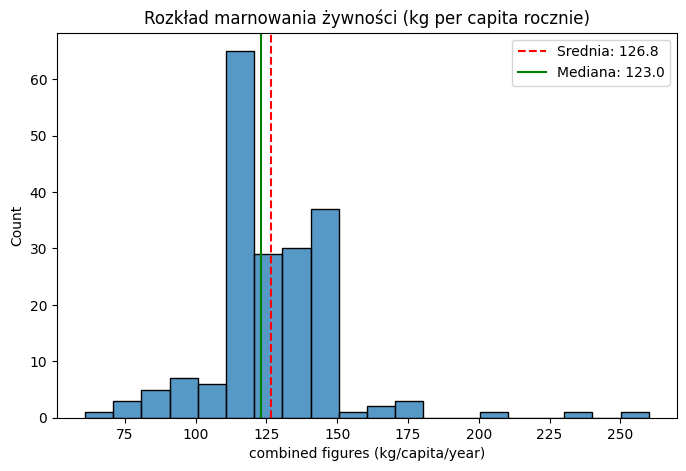

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

col = 'combined figures (kg/capita/year)'

mean_value = analysis[col].mean()
median_value = analysis[col].median()

plt.figure(figsize=(8,5))
sns.histplot(analysis[col], bins=20)

plt.axvline(mean_value, color='red', linestyle='--', label=f'Srednia: {mean_value:.1f}')
plt.axvline(median_value, color='green', linestyle='-', label=f'Mediana: {median_value:.1f}')

plt.title("Rozkład marnowania żywności (kg per capita rocznie)")
plt.legend()
plt.show()

Średnia wartość marnowania żywności wynosi 126,8 kg per capita rocznie, natomiast mediana 123 kg. Niewielka różnica między tymi miarami wskazuje, że rozkład danych jest stosunkowo symetryczny, bez wyraźnej asymetrii.
Oznacza to, że większość krajów koncentruje się wokół zbliżonych wartości, a wpływ skrajnych obserwacji na średnią globalną jest ograniczony.
Zakres danych (ok. 50-265 kg) świadczy jednak o istotnym zróżnicowaniu maronowania żywności między państwami.

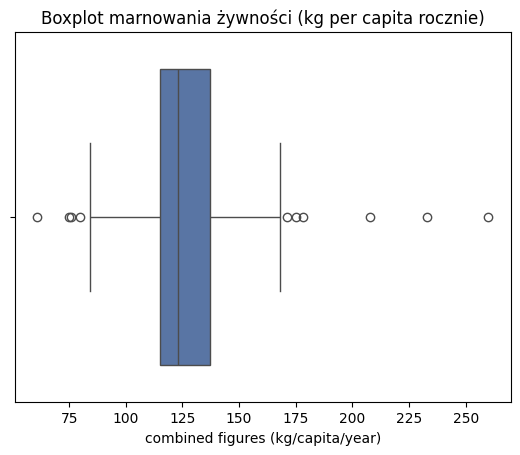

In [16]:
sns.boxplot(x=analysis[col], color="#4C72B0")
plt.title("Boxplot marnowania żywności (kg per capita rocznie)")
plt.show()

In [17]:
Q1 = analysis[col].quantile(0.25)
Q3 = analysis[col].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = analysis[(analysis[col] < lower_bound) | (analysis[col] > upper_bound)]
outliers_count = len(outliers)
print(f"Liczba wartości odstających (IQR): {outliers_count}")

Liczba wartości odstających (IQR): 10


Zastosowanie metody IQR pozwoliło zidentyfikować 10 wartości odstających. Analiza boxplota wskazuje, że wartości te dotyczą przede wszystkim krajów o wysokim poziomie marnowania żywności (powyżej 200 kg per capita rocznie), natomiast pojedyncze przypadki odnoszą się do niższych wartości. Wartości odstające nie zostały usunięte z analizy, ponieważ odzwierciedlają rzeczywiste zróżnicowanie między państwami.

In [18]:
analysis.groupby('Income group')['combined figures (kg/capita/year)'].agg(['mean','median','count']).sort_values(by='mean', ascending=False)

,mean,median,count
Income group,,,
Low income,146.214286,147.0,28
Lower middle income,133.410256,135.0,39
Upper middle income,124.000000,120.0,55
High income,117.428571,115.0,70


Wyniki wskazują, że kraje o wyższym poziomie dochodu charakteryzują się niższym średnim poziomem marnowania żywności per capita.. Najwyższe średnie poziomy odnotowano w krajach o niskim poziomie dochodu (146,2 kg per capita), natomiast najniższe w krajach wysokodochodowych (117,4 kg per capita). Trend ten jest spójny również dla mediany, co potwierdza stabilność obserwowanej zależności.
W świetle uzyskanych wyników hipoteza H1 nie znajduje potwierdzenia w analizowanych danych.

Należy zauważyć, że grupa krajów wysokodochodowych obejmuje 70 państw, podczas gdy grupa niskodochodowa 28, co może wpływać na stabilność oszacowań średnich wartości.

In [19]:
analysis['Region'].value_counts()

,count
Region,
Sub-Saharan Africa,43
Latin America and the Caribbean,36
Western Asia,17
Southern Europe,15
Northern Europe,12
South-eastern Asia,10
Southern Asia,9
Western Europe,9
Eastern Europe,8


In [20]:
analysis.groupby('Region')['combined figures (kg/capita/year)'] \
    .agg(['mean','median','count']) \
    .sort_values(by='mean', ascending=False)

,mean,median,count
Region,,,
Western Asia,145.411765,137.0,17
Sub-Saharan Africa,145.046512,144.0,43
South-eastern Asia,138.200000,126.5,10
Northern Africa,133.500000,135.0,6
Central Asia,129.000000,127.5,4
Melanesia,128.600000,135.0,5
Southern Europe,123.000000,123.0,15
Micronesia,121.166667,118.0,6
Polynesia,119.500000,120.0,4


In [21]:
order = analysis.groupby('Region')['combined figures (kg/capita/year)']\
    .mean()\
    .sort_values(ascending=False)\
    .index

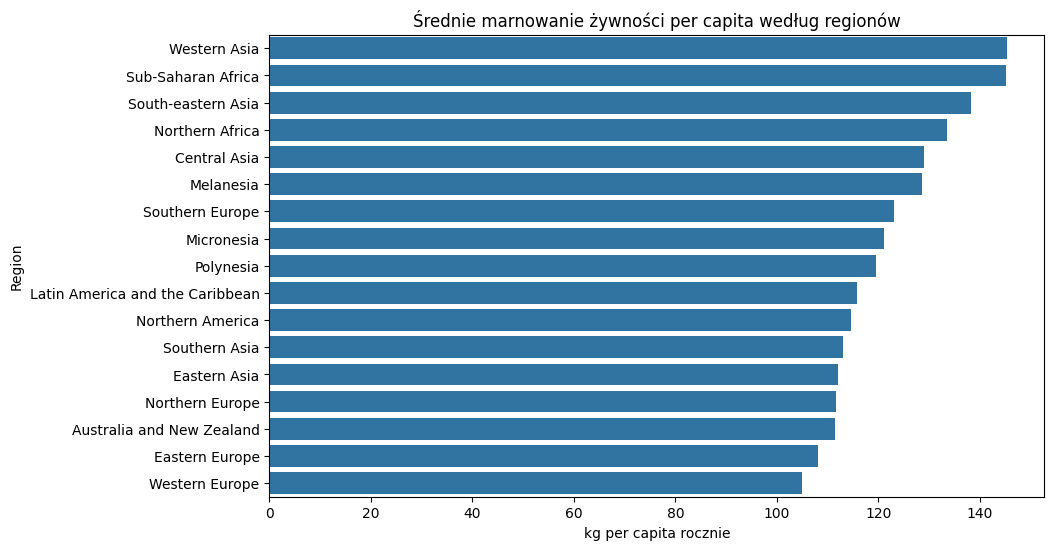

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=analysis,
    y='Region',
    x='combined figures (kg/capita/year)',
    order=order,
    estimator='mean',
    errorbar=None
)

plt.title("Średnie marnowanie żywności per capita według regionów")
plt.xlabel("kg per capita rocznie")
plt.ylabel("Region")

plt.show()

Analiza regionalna wskazuje na zauważalne zróżnicowanie poziomu marnowania żywności pomiędzy regionami świata. Najwyższe średnie wartości odnotowano w regionach Western Asia oraz Sub-Saharan Africa, gdzie średni poziom marnowania przekracza 140 kg per capita rocznie. Relatywnie wysokie wartości obserwowane są również w South-eastern Asia oraz Northern Africa.
Najniższe średnie poziomy marnowania żywności odnotowano natomiast w regionach europejskich, szczególnie w Western Europe oraz Eastern Europe, gdzie wartości te wynoszą około 105–110 kg per capita rocznie.
Różnice pomiędzy regionami sięgają około 40 kg per capita rocznie, co wskazuje, że czynniki regionalne mogą stanowić istotny element wpływający na skalę marnowania żywności.

In [23]:
region_means = analysis.groupby('Region')['combined figures (kg/capita/year)'].mean()

max_region = region_means.max()
min_region = region_means.min()

difference = max_region - min_region

print(f"Najwyższa średnia: {max_region:.1f}")
print(f"Najniższa średnia: {min_region:.1f}")
print(f"Różnica: {difference:.1f} kg per capita rocznie")

Najwyższa średnia: 145.4
Najniższa średnia: 104.9
Różnica: 40.5 kg per capita rocznie


Różnica pomiędzy regionem o najwyższym oraz najniższym średnim poziomie marnowania żywności wynosi około 40,5 kg per capita rocznie, co wskazuje na istotne zróżnicowanie regionalne.

Który sektor odpowiada za największy poziom marnowania żywności?

In [24]:
sector_means = {
    'Household': analysis['Household estimate (kg/capita/year)'].mean(),
    'Retail': analysis['Retail estimate (kg/capita/year)'].mean(),
    'Food service': analysis['Food service estimate (kg/capita/year)'].mean()
}

sector_means

{'Household': np.float64(84.43229166666667),
 'Retail': np.float64(15.125),
 'Food service': np.float64(27.197916666666668)}

In [25]:
sector_df = pd.DataFrame(list(sector_means.items()), columns=['Sector', 'Mean waste'])

sector_df

,Sector,Mean waste
0,Household,84.432292
1,Retail,15.125000
2,Food service,27.197917


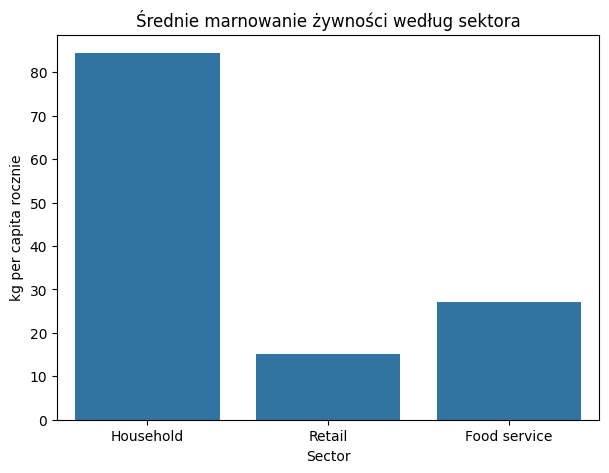

In [26]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=sector_df,
    x='Sector',
    y='Mean waste',
    errorbar=None
)

plt.title("Średnie marnowanie żywności według sektora")
plt.ylabel("kg per capita rocznie")

plt.show()

Analiza sektorów marnowania żywności wskazuje, że zdecydowanie największy udział w całkowitej skali marnowania przypada na gospodarstwa domowe. Średni poziom marnowania w tym sektorze wynosi około 85 kg per capita rocznie, co jest znacząco wyższą wartością niż w sektorze usług gastronomicznych (ok. 27 kg) oraz handlu detalicznego (ok. 15 kg).
Wyniki te sugerują, że działania mające na celu ograniczenie marnowania żywności powinny w dużej mierze koncentrować się na poziomie gospodarstw domowych.
Oznacza to, że gospodarstwa domowe odpowiadają za największą część marnowania żywności w analizowanych danych.

In [27]:
top_waste = analysis[['Country', 'combined figures (kg/capita/year)']] \
    .sort_values(by='combined figures (kg/capita/year)', ascending=False) \
    .head(10)

top_waste

,Country,combined figures (kg/capita/year)
116,Malaysia,260
139,Nigeria,233
159,Rwanda,208
95,Israel,178
77,Greece,175
13,Bahrain,171
119,Malta,168
92,Iraq,164
167,Saudi Arabia,151
107,Lebanon,149


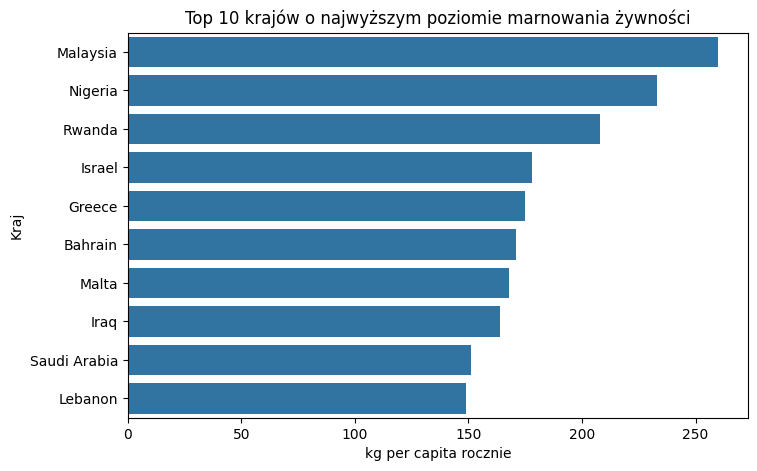

In [28]:
# @title
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_waste,
    y='Country',
    x='combined figures (kg/capita/year)',
    errorbar=None
)

plt.title("Top 10 krajów o najwyższym poziomie marnowania żywności")
plt.xlabel("kg per capita rocznie")
plt.ylabel("Kraj")

plt.show()

In [29]:
lowest_waste = analysis[['Country', 'combined figures (kg/capita/year)']] \
    .sort_values(by='combined figures (kg/capita/year)', ascending=True) \
    .head(10)

lowest_waste

,Country,combined figures (kg/capita/year)
175,Slovenia,61
158,Russia,75
10,Austria,76
17,Belgium,80
14,Bangladesh,84
178,South Africa,84
134,Netherlands,87
98,Japan,88
136,New Zealand,90
89,India,94


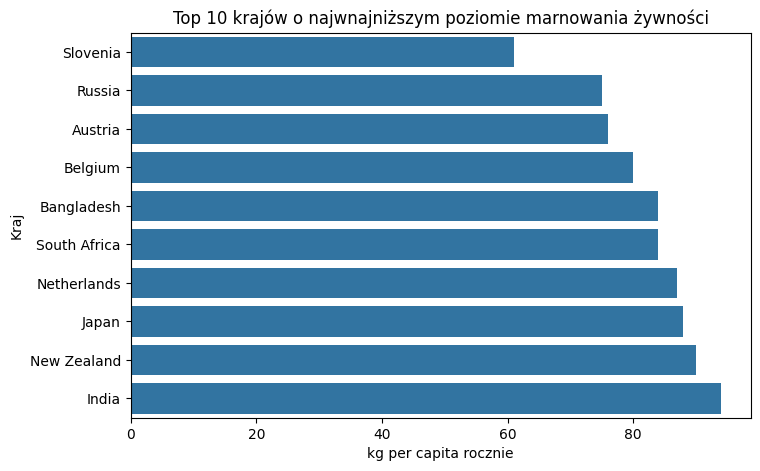

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=lowest_waste,
    y='Country',
    x='combined figures (kg/capita/year)',
    errorbar=None
)

plt.title("Top 10 krajów o najwnajniższym poziomie marnowania żywności")
plt.xlabel("kg per capita rocznie")
plt.ylabel("Kraj")

plt.show()

In [31]:
polska = analysis[analysis["Country"] == "Poland"]["combined figures (kg/capita/year)"].values[0]
srednia_swiat = analysis["combined figures (kg/capita/year)"].mean()

print("Polska:", polska)
print("Średnia światowa:", srednia_swiat)

Polska: 95
Średnia światowa: 126.75520833333333


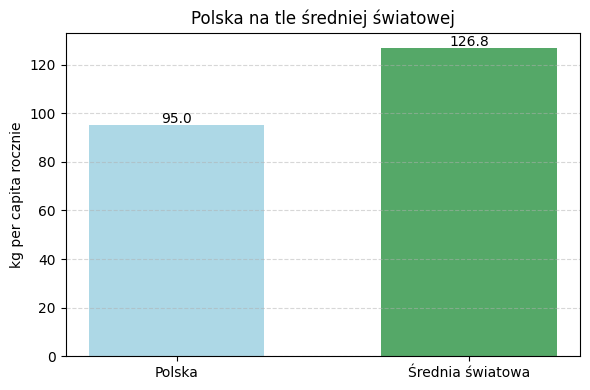

In [32]:
plt.figure(figsize=(6,4))

labels = ["Polska", "Średnia światowa"]
values = [polska, srednia_swiat]

bars = plt.bar(range(len(labels)), values, width=0.6, color=["lightblue", "#55A868"])

plt.xticks(range(len(labels)), labels)

plt.title("Polska na tle średniej światowej")
plt.ylabel("kg per capita rocznie")

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

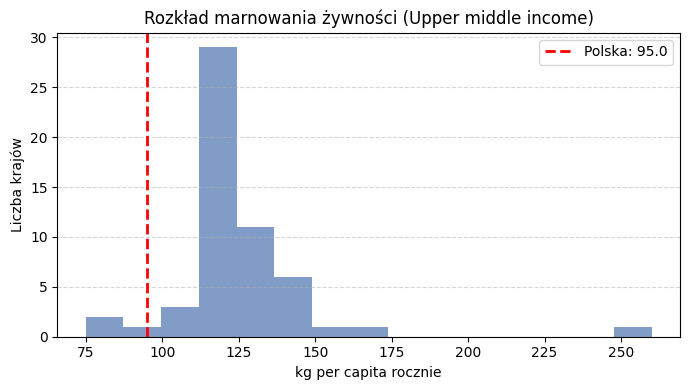

In [33]:
subset = analysis[analysis["Income group"] == "Upper middle income"]

plt.figure(figsize=(7,4))

plt.hist(
    subset["combined figures (kg/capita/year)"],
    bins=15,
    color="#4C72B0",
    alpha=0.7
)

plt.axvline(
    polska,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Polska: {polska:.1f}"
)

plt.title("Rozkład marnowania żywności (Upper middle income)")
plt.xlabel("kg per capita rocznie")
plt.ylabel("Liczba krajów")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

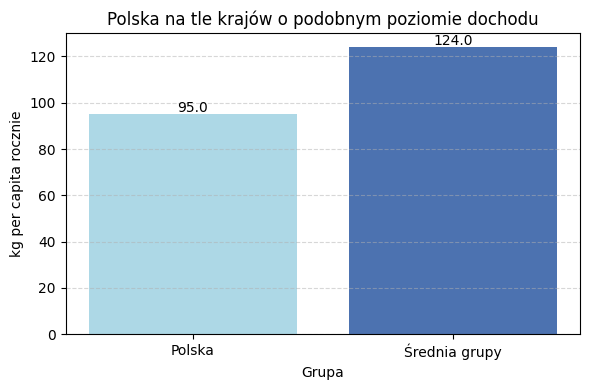

In [34]:
srednia_grupy = subset["combined figures (kg/capita/year)"].mean()

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Polska", "Średnia grupy"],
    [polska, srednia_grupy],
    color=["lightblue", "#4C72B0"]
)

plt.title("Polska na tle krajów o podobnym poziomie dochodu")
plt.xlabel("Grupa")
plt.ylabel("kg per capita rocznie")

# wartości nad słupkami
for i, v in enumerate([polska, srednia_grupy]):
    plt.text(i, v + 1, f"{v:.1f}", ha='center')

# siatka (jak w innych wykresach)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Analiza krajów o najwyższym oraz najniższym poziomie marnowania żywności wskazuje na znaczne zróżnicowanie pomiędzy państwami. Wśród krajów o najwyższych poziomach marnowania wartości przekraczają 250 kg per capita rocznie, natomiast w krajach o najniższych poziomach wynoszą około 60–90 kg per capita rocznie.
Oznacza to, że różnica pomiędzy skrajnymi przypadkami może sięgać około 200 kg per capita rocznie, co wskazuje na dużą skalę zróżnicowania pomiędzy poszczególnymi krajami.
Jednocześnie kraje znajdujące się w obu zestawieniach reprezentują różne regiony świata oraz poziomy rozwoju gospodarczego, co sugeruje, że na poziom marnowania żywności mogą wpływać różnorodne czynniki.

Dodatkowa analiza wskazuje, że poziom marnowania żywności w Polsce wynosi około 95 kg per capita rocznie, co jest wartością niższą niż średnia światowa (ok. 126,8 kg).

Na tle krajów o podobnym poziomie dochodu Polska również osiąga wartości niższe od średniej dla tej grupy, co wskazuje na relatywnie mniejszą skalę problemu w porównaniu do innych państw o zbliżonym poziomie rozwoju.

Analiza rozkładu dla krajów z tej samej grupy dochodowej pokazuje, że Polska znajduje się w dolnej części zakresu wartości, co potwierdza, że poziom marnowania żywności w tym kraju nie odbiega istotnie od innych państw.

**Wnioski końcowe:**

Przeprowadzona analiza danych dotyczących marnowania żywności na świecie pozwala sformułować kilka głównych wniosków.

1. Zróżnicowanie poziomu marnowania żywności pomiędzy krajami jest bardzo duże.
Analiza rozkładu danych pokazuje, że wartości marnowania żywności per capita mieszczą się w szerokim zakresie - od około 60 kg do ponad 250 kg rocznie. Wskazuje to na znaczne różnice pomiędzy poszczególnymi państwami.

2. Poziom dochodu kraju nie zawsze oznacza wyższe marnowanie żywności.
Analiza średnich wartości dla grup dochodowych wskazuje, że kraje o wyższym poziomie dochodu charakteryzują się niższym średnim poziomem marnowania żywności per capita niż kraje o niższych dochodach. Oznacza to, że hipoteza zakładająca większe marnowanie żywności w krajach wysokodochodowych nie znalazła potwierdzenia w analizowanych danych.

3. Występują istotne różnice regionalne w poziomie marnowania żywności.
Najwyższe średnie poziomy marnowania żywności odnotowano w regionach takich jak Western Asia oraz Sub-Saharan Africa, natomiast najniższe wartości obserwowane są w regionach europejskich. Różnica pomiędzy regionem o najwyższym oraz najniższym poziomie marnowania wynosi około 40 kg per capita rocznie.

4. Największy udział w marnowaniu żywności mają gospodarstwa domowe.
Analiza sektorów wskazuje, że gospodarstwa domowe odpowiadają za zdecydowanie największą część marnowania żywności (ok. 85 kg per capita rocznie), podczas gdy wartości w sektorze gastronomicznym i handlu detalicznego są znacznie niższe.

5. Na poziom marnowania żywności mogą wpływać różnorodne czynniki.
Analiza wskazuje, że różnice pomiędzy krajami i regionami są znaczne, co sugeruje, że na skalę marnowania żywności mogą wpływać różne czynniki, takie jak struktura gospodarki, organizacja systemów dystrybucji żywności czy zachowania konsumenckie. Dokładniejsze określenie tych zależności wymagałoby jednak uwzględnienia dodatkowych danych.